Connected to base (Python 3.12.4)

  2-D Site Percolation  —  critical exponent analysis

[1/7] Coarse sweep  L=16, runs=50 ...


[1/7] Coarse sweep  L=16: 100%|██████████| 20/20 p-points [00:01<00:00, 12.44p-point/s]


    pc (coarse) ≈ 0.59158  [theory: 0.59274]
  Saved: figures/coarse_observables.png

[2/7] Fine sweep  L=16, runs=100 ...


[2/7] Fine sweep    L=16: 100%|██████████| 30/30 p-points [00:04<00:00,  6.70p-point/s]


    pc (fine)   ≈ 0.59017  [theory: 0.59274]
  Saved: figures/fine_observables.png

[3/7] Finite-size scaling  L = [16, 32] ...


...

  Saved: figures/beta_fit.png
  Plotting gamma_fit ...
  Saved: figures/gamma_fit.png
  Plotting tau_fit ...
  Saved: figures/tau_fit.png

[5b] Scaling correction window scan ...


  Window scan (beta): 100%|██████████| 485/485 [00:00<00:00]


    Best beta window: xmin=0.0100, xmax=0.0434  →  beta=0.1370  (theory 0.1389)
  Saved: figures/scaling_window_beta.png


  Window scan (gamma):   0%|          | 0/485 [00:00<?]/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.lo

  Saved: figures/scaling_window_gamma.png

[6/9] Data collapse  (L = [16, 32]) ...
  Plotting collapse (R) ...
  Saved: figures/collapse_R.png
  Plotting collapse (chi) ...
  Saved: figures/collapse_chi.png
  Plotting collapse (Pinf) ...
  Saved: figures/collapse_Pinf.png

[7/9] Summary figure and Newman-Ziff ...
  Plotting summary figure ...
  Saved: figures/summary.png
  Running Newman-Ziff ...
  Saved: figures/newman_ziff.png

[8/9] Fractal dimension ...
  Fitting d_f from 2 lattice sizes ...
  Saved: figures/fractal_dimension.png
    d_f = 1.7701  [theory: 1.8958]

Done. All figures saved to: figures

[ML step skipped — set RUN_ML=True to enable]


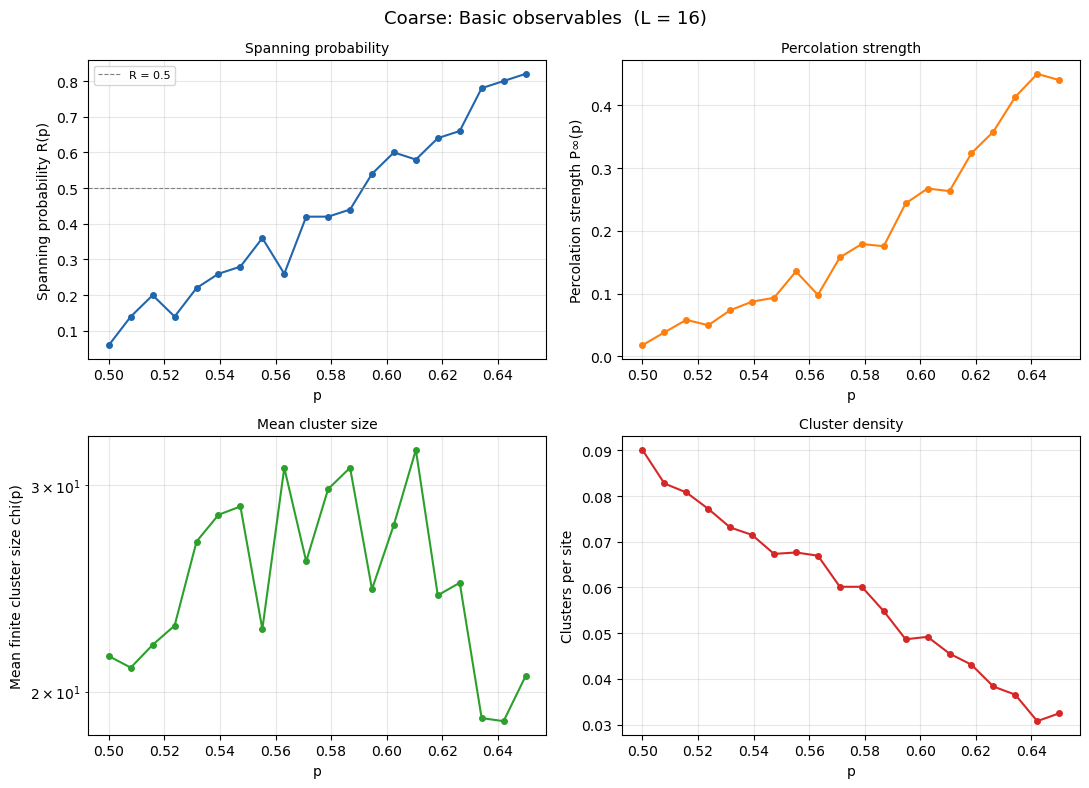

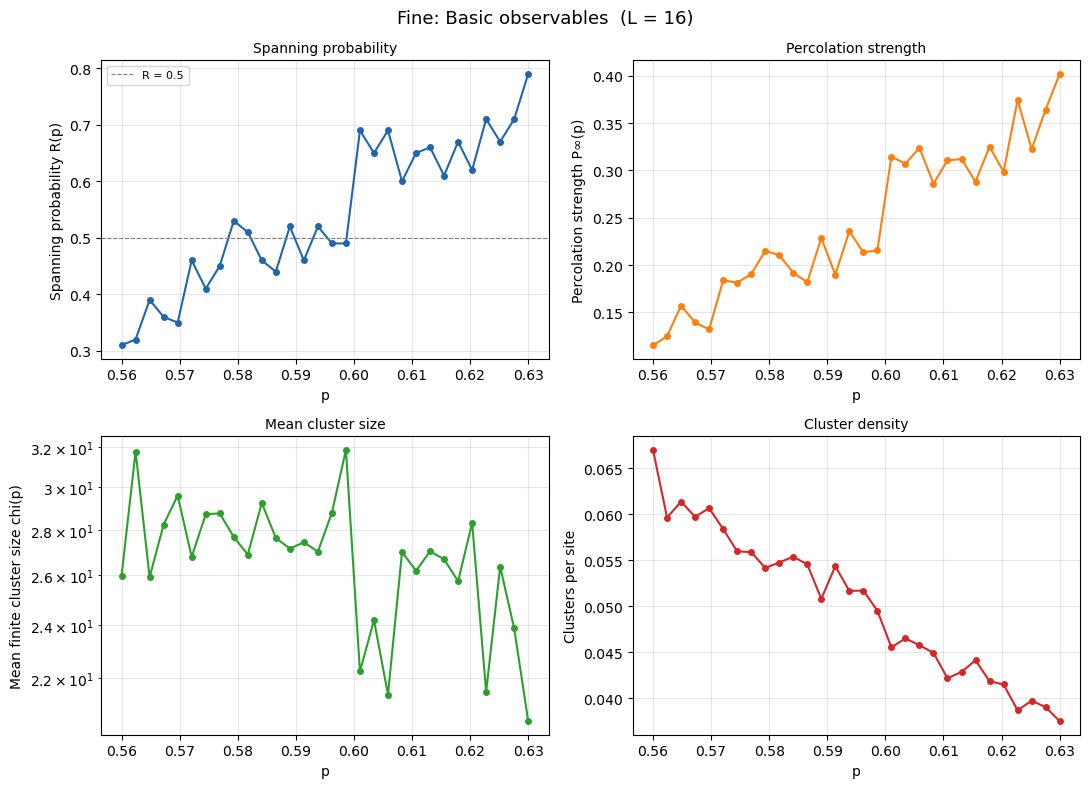

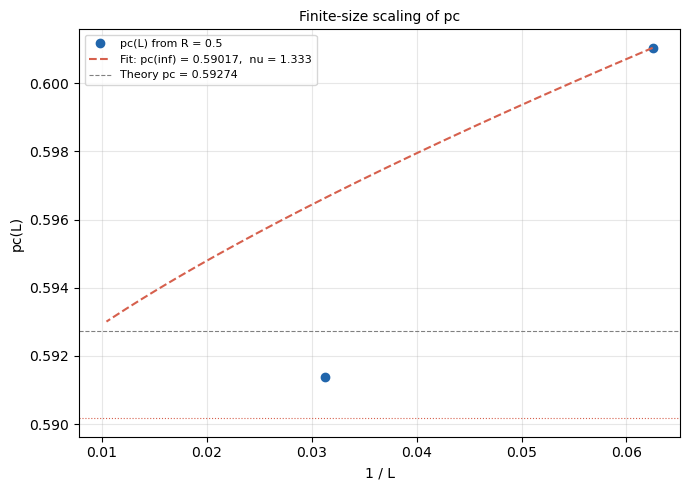

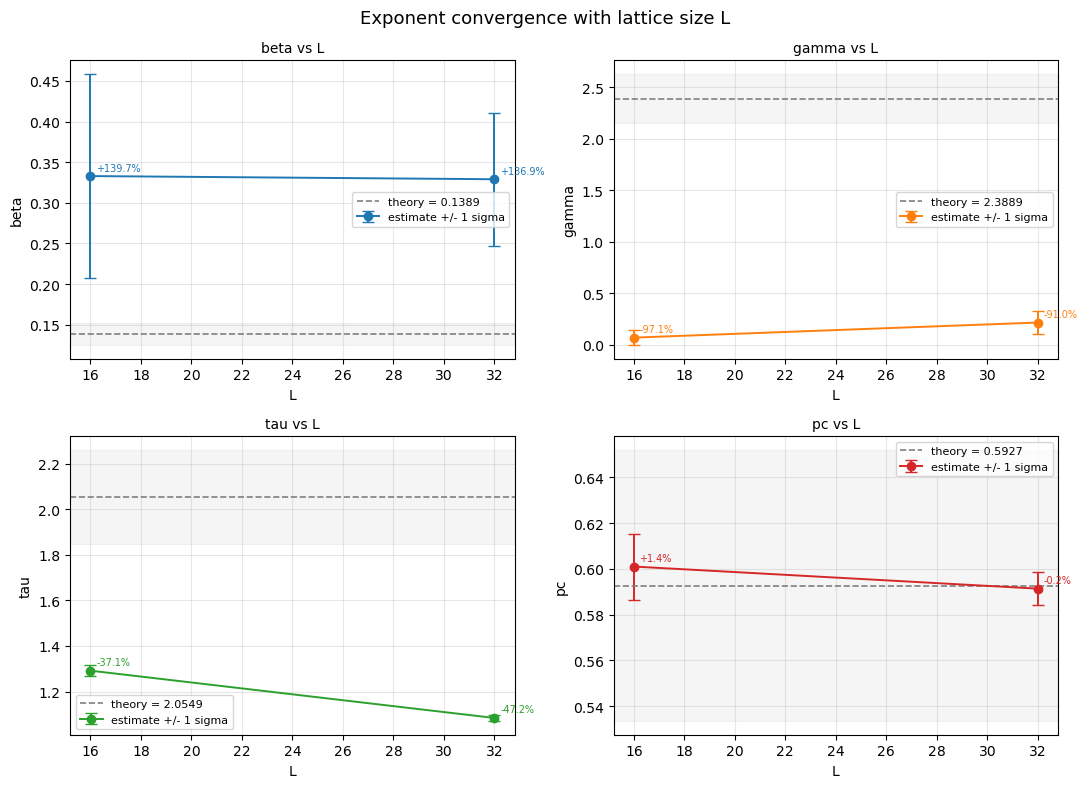

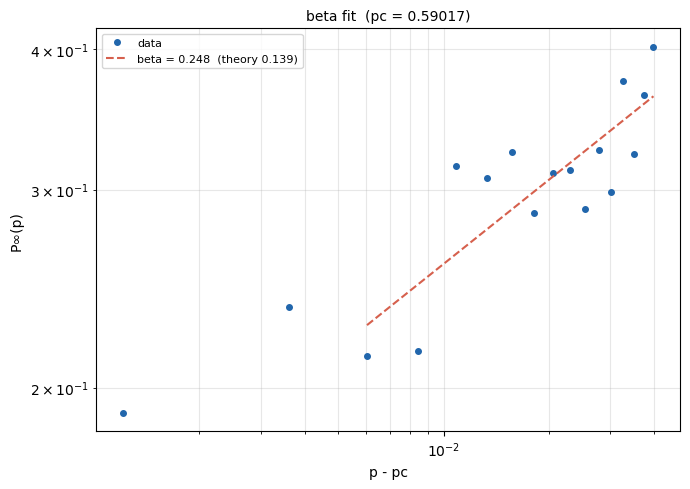

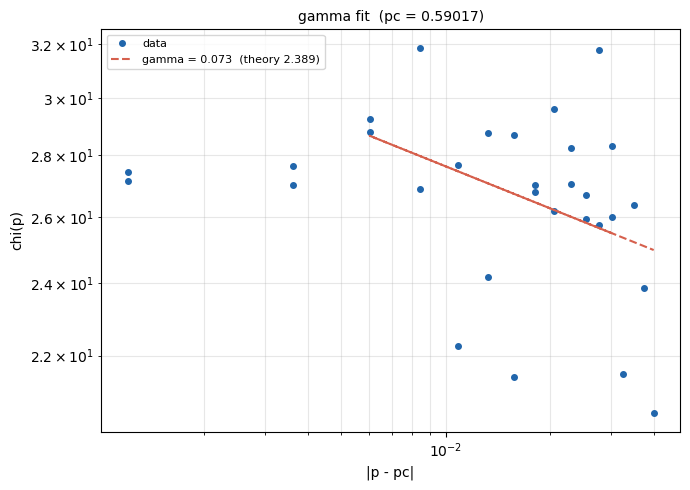

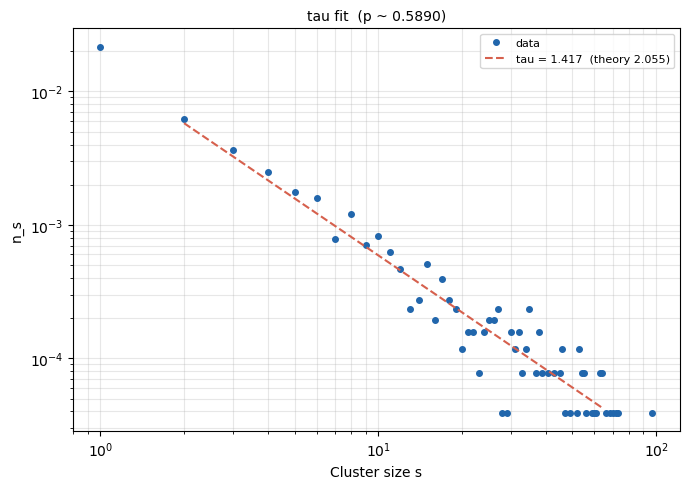

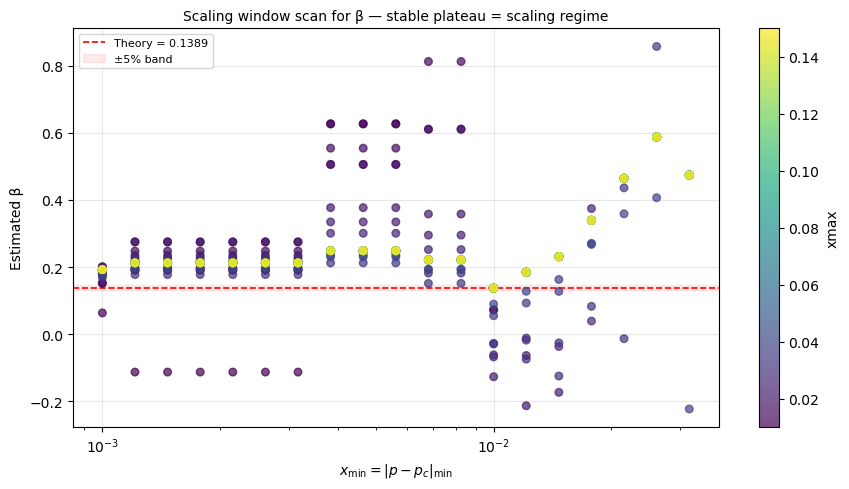

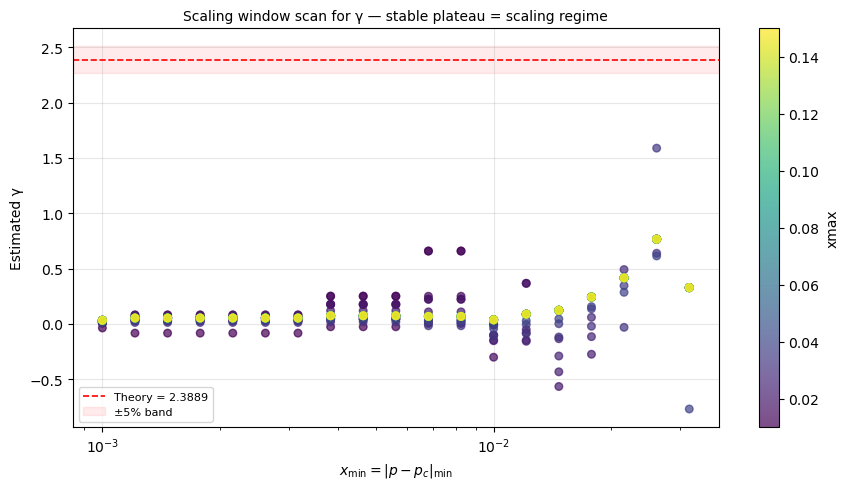

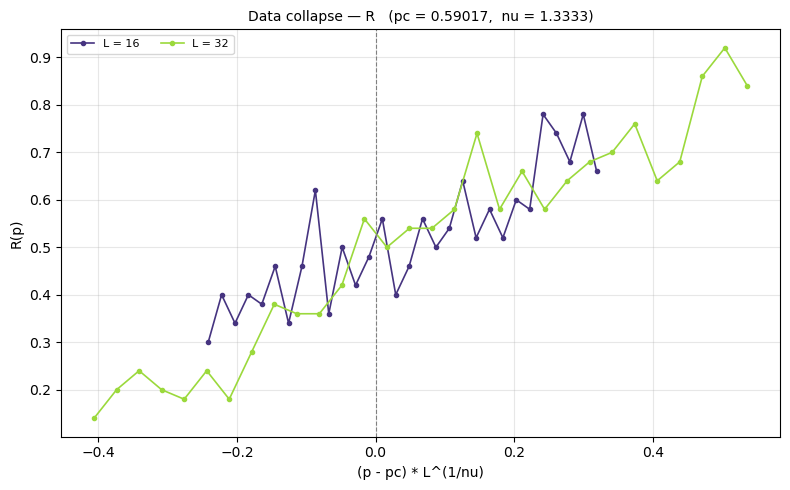

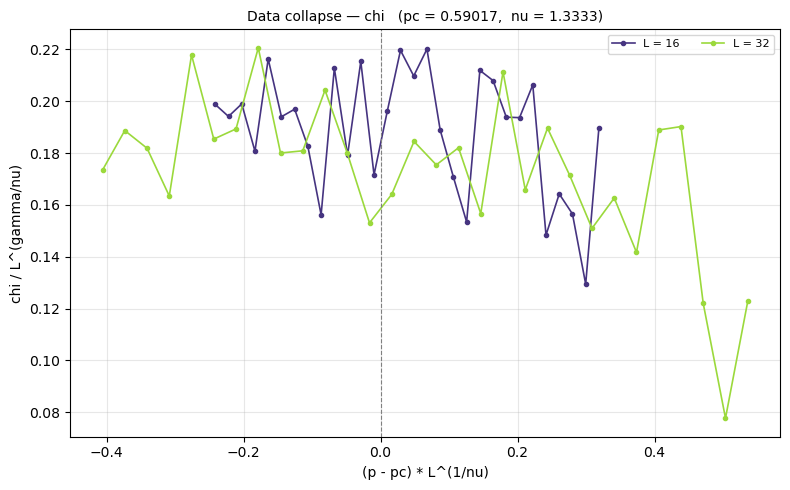

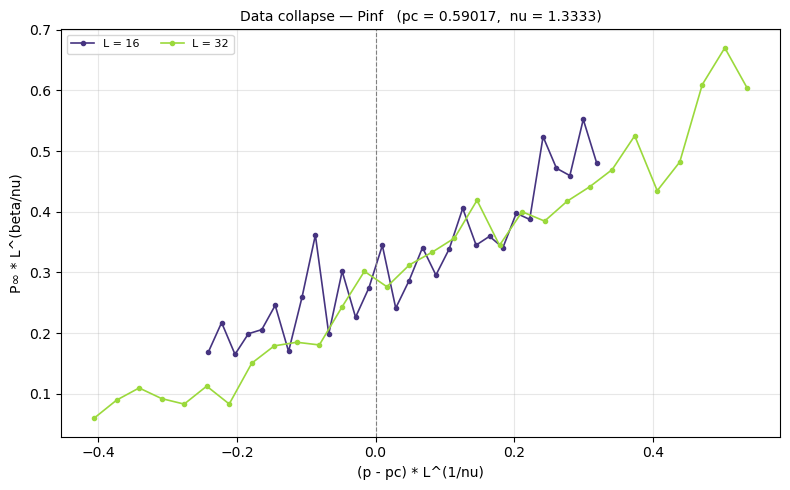

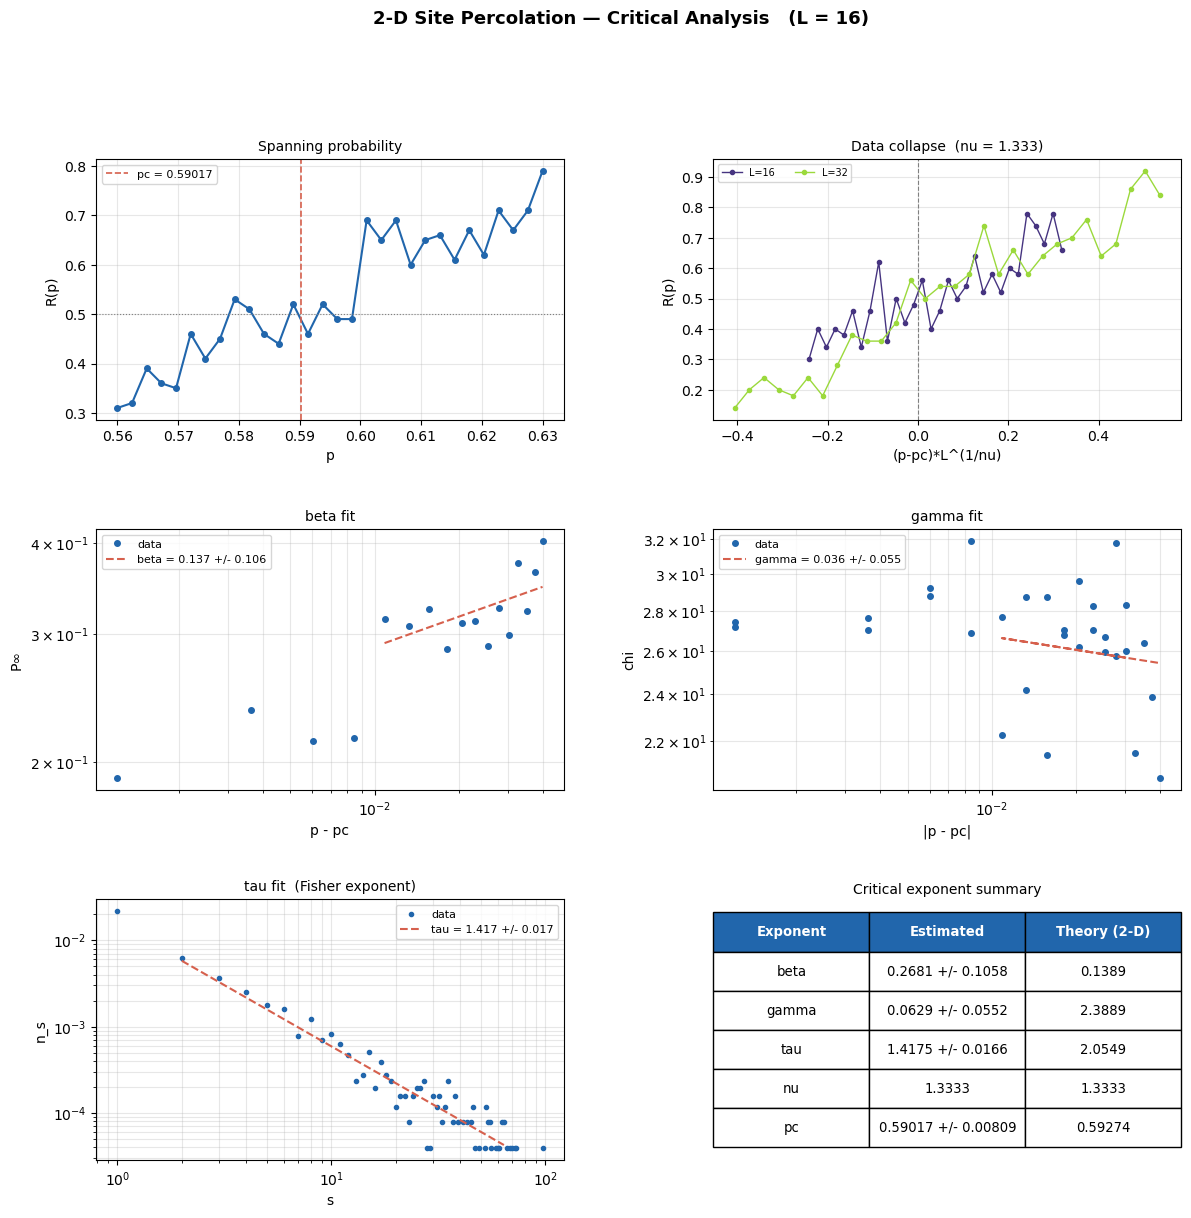

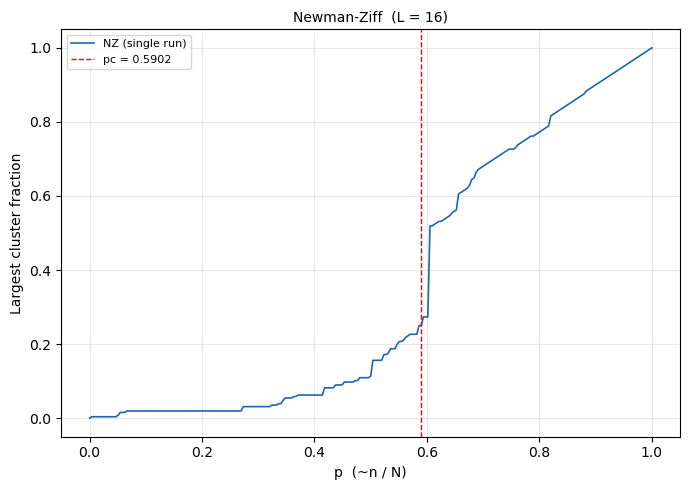

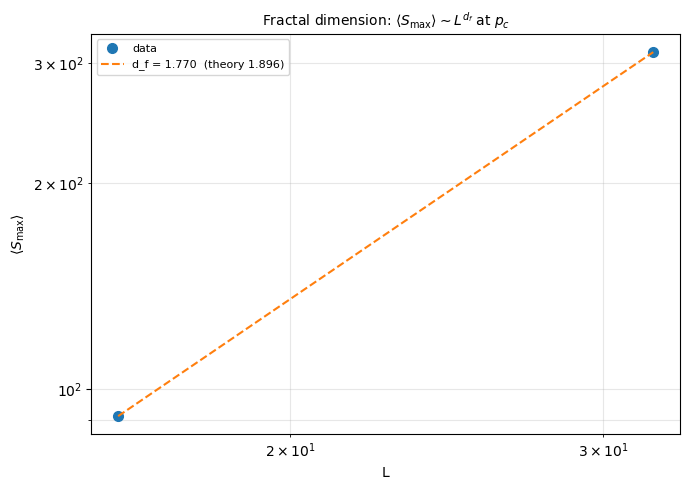

In [ ]:
"""
main.py
-------
Main entry point for the 2-D site-percolation study.

Workflow (9 steps)
------------------
1. Coarse sweep over p at L_MAIN to locate pc roughly.
2. Fine sweep near pc with more runs (stores per-run data for bootstrap).
3. FSS loop: pc(L), exponents, fractal dimension, uncertainties at each L.
4. Bootstrap uncertainties on the fine-sweep data.
5. Extract and print exponents with error bars.
5b. Scaling correction window scans for beta and gamma.
6. Data collapse using the FSS results.
7. Summary figure and Newman-Ziff cross-check.
8. Fractal dimension plot from FSS data.
9. CNN phase classifier: train at each L, compare pc convergence to FSS.

Edit the configuration block below to trade speed for accuracy.
Set RUN_ML = False to skip the ML step entirely.
"""

import os
import numpy as np
import matplotlib

from algorithms import hoshen_kopelman, newman_ziff
from simulation import estimate_observables_over_p
from analysis   import (
    estimate_pc_single_L, estimate_pc_fss,
    estimate_beta, estimate_gamma, estimate_tau,
    bootstrap_uncertainties, full_exponent_report,
    scaling_window_scan, optimal_window, THEORY,
)
from plotting import (
    plot_basic_observables, plot_beta_fit, plot_gamma_fit,
    plot_tau_fit, plot_nz_curve, plot_pc_fss,
    plot_data_collapse, plot_summary, plot_exponent_convergence,
    plot_df_fit, plot_scaling_window, plot_ml_convergence,
)

# =============================================================================
# Configuration — edit here
# =============================================================================

L_MAIN      = 16               # primary lattice size
L_FSS       = [16, 32]  # sizes for finite-size scaling

RUNS_COARSE = 50               # runs for broad sweep and FSS loop
RUNS_FINE   = 100               # runs for fine sweep (more = better exponents)

P_COARSE    = np.linspace(0.50, 0.65, 20)   # broad grid to find pc
P_FINE      = np.linspace(0.56, 0.63, 30)   # narrow grid for fitting

SPAN_MODE   = "LR"              # spanning direction: "LR", "TB", or "ANY"

BETA_XMIN,  BETA_XMAX  = 0.005, 0.06   # fitting window for beta
GAMMA_XMIN, GAMMA_XMAX = 0.005, 0.06   # fitting window for gamma

# Scaling correction window scan — range of xmin/xmax values to probe
SCAN_XMINS = np.logspace(-3, -1, 25)
SCAN_XMAXS = np.logspace(-2, np.log10(0.15), 25)

N_BOOT      = 500               # bootstrap resamples (reduce for speed)
BASE_SEED   = 42                # set None for non-reproducible runs
FIG_DIR     = "figures"         # folder for saved figures ("" to skip)

# ML configuration
RUN_ML          = False          # set False to skip the ML step entirely
ML_EPOCHS       = 25            # training epochs (20-30 is usually enough)
ML_SAMPLES_PER_P= 300           # lattices per p value for training
ML_P_GAP        = 0.04          # half-width of gap around pc in training data
ML_EVAL_SAMPLES = 300           # lattices per p for the pc curve

# =============================================================================
# Helpers
# =============================================================================

def _save(fig, name):
    if FIG_DIR:
        os.makedirs(FIG_DIR, exist_ok=True)
        path = os.path.join(FIG_DIR, f"{name}.png")
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {path}")


def _run(L, p_values, runs, seed_offset=0, return_runs=False, desc=None):
    """Convenience wrapper around estimate_observables_over_p."""
    return estimate_observables_over_p(
        L=L, p_values=p_values, runs=runs,
        span_mode=SPAN_MODE, n_jobs=-1,
        base_seed=BASE_SEED + seed_offset,
        return_runs=return_runs,
        desc=desc,
    )


def _collect_estimates(res, pc_L, L_val):
    """Extract point estimates from a single-L results dict."""
    est = {"pc": pc_L}
    k   = int(np.argmin(np.abs(res["p"] - pc_L)))
    for key, fn, obs in [("beta",  estimate_beta,  res["Pinf"]),
                          ("gamma", estimate_gamma, res["chi"])]:
        try:
            est[key], _, _ = fn(res["p"], obs, pc_L,
                                xmin=BETA_XMIN if key=="beta" else GAMMA_XMIN,
                                xmax=BETA_XMAX if key=="beta" else GAMMA_XMAX)
        except Exception:
            est[key] = None
    try:
        est["tau"], _, _, _ = estimate_tau(res["ns_density"][k],
                                           smin=2, smax=L_val*L_val//4)
    except Exception:
        est["tau"] = None
    return est

# =============================================================================
# Main
# =============================================================================

def main():
    print("=" * 60)
    print("  2-D Site Percolation  —  critical exponent analysis")
    print("=" * 60)

    # ------------------------------------------------------------------
    # Step 1: Coarse sweep
    # ------------------------------------------------------------------
    print(f"\n[1/7] Coarse sweep  L={L_MAIN}, runs={RUNS_COARSE} ...")
    coarse   = _run(L_MAIN, P_COARSE, RUNS_COARSE,
                    desc=f"[1/7] Coarse sweep  L={L_MAIN}")
    pc_coarse = estimate_pc_single_L(coarse["p"], coarse["R"])
    print(f"    pc (coarse) ≈ {pc_coarse:.5f}  [theory: {THEORY['pc']:.5f}]")
    _save(plot_basic_observables(coarse, L_MAIN, "Coarse: "), "coarse_observables")

    # ------------------------------------------------------------------
    # Step 2: Fine sweep  (stores per-run arrays for bootstrap)
    # ------------------------------------------------------------------
    print(f"\n[2/7] Fine sweep  L={L_MAIN}, runs={RUNS_FINE} ...")
    fine    = _run(L_MAIN, P_FINE, RUNS_FINE, seed_offset=10000,
                   return_runs=True,
                   desc=f"[2/7] Fine sweep    L={L_MAIN}")
    pc_fine = estimate_pc_single_L(fine["p"], fine["R"])
    print(f"    pc (fine)   ≈ {pc_fine:.5f}  [theory: {THEORY['pc']:.5f}]")
    _save(plot_basic_observables(fine, L_MAIN, "Fine: "), "fine_observables")

    # ------------------------------------------------------------------
    # Step 3: FSS loop — pc(L), exponents, uncertainties at each L
    # ------------------------------------------------------------------
    print(f"\n[3/7] Finite-size scaling  L = {L_FSS} ...")
    pc_of_L, results_by_L, estimates_by_L, uncertainties_by_L = [], {}, {}, {}
    Smax_at_pc = {}   # {L_val: mean largest cluster size at pc} for d_f fit

    for L_val in L_FSS:
        res = _run(L_val, P_FINE, RUNS_COARSE,
                   seed_offset=20000 + L_val, return_runs=True,
                   desc=f"[3/7] FSS  L={L_val:4d}")
        results_by_L[L_val] = res

        try:    pc_L = estimate_pc_single_L(res["p"], res["R"])
        except: pc_L = np.nan; print(f"    Warning: R(p) misses 0.5 for L={L_val}")
        pc_of_L.append(pc_L)
        print(f"    L = {L_val:4d}  →  pc(L) = {pc_L:.5f}")

        # Largest cluster at the p closest to pc — used for fractal dimension
        k_pc = int(np.argmin(np.abs(res["p"] - pc_L)))
        Smax_at_pc[L_val] = float(res["Smax"][k_pc])

        estimates_by_L[L_val] = _collect_estimates(res, pc_L, L_val)

        try:
            uncertainties_by_L[L_val] = bootstrap_uncertainties(
                res, pc_L, n_boot=min(N_BOOT, 200),
                beta_xmin=BETA_XMIN, beta_xmax=BETA_XMAX,
                gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
                L=L_val,
                rng=np.random.default_rng(BASE_SEED + 30000 + L_val),
            )
        except Exception as e:
            print(f"    Bootstrap for L={L_val} failed: {e}")

    L_arr    = np.array(L_FSS,   dtype=float)
    pc_L_arr = np.array(pc_of_L, dtype=float)
    valid    = np.isfinite(pc_L_arr)

    pc_best, nu_fit = pc_fine, THEORY["nu"]
    if valid.sum() >= 3:
        try:
            pc_best, nu_fit, _ = estimate_pc_fss(L_arr[valid], pc_L_arr[valid])
            print(f"\n    FSS: pc(∞) = {pc_best:.5f},  nu = {nu_fit:.4f}"
                  f"  [theory nu = {THEORY['nu']:.4f}]")
        except Exception as e:
            print(f"    FSS fit failed: {e}; using single-L pc.")
    else:
        print("    Not enough valid points for FSS; using single-L pc.")

    print(f"\n  *** Best pc: {pc_best:.5f}  (theory: {THEORY['pc']:.5f}) ***")

    _save(plot_pc_fss(L_arr[valid], pc_L_arr[valid],
                      pc_inf=pc_best, nu=nu_fit), "pc_fss")
    _save(plot_exponent_convergence(L_arr[valid], estimates_by_L,
                                    uncertainties_by_L), "exponent_convergence")

    # ------------------------------------------------------------------
    # Step 4: Bootstrap on fine sweep
    # ------------------------------------------------------------------
    print(f"\n[4/7] Bootstrap uncertainties  (n_boot={N_BOOT}) ...")
    unc = bootstrap_uncertainties(
        fine, pc_best, n_boot=N_BOOT,
        beta_xmin=BETA_XMIN, beta_xmax=BETA_XMAX,
        gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
        L=L_MAIN, rng=np.random.default_rng(BASE_SEED + 50000),
    )

    # ------------------------------------------------------------------
    # Step 5: Exponent report
    # ------------------------------------------------------------------
    print(f"\n[5/7] Extracting critical exponents ...")
    full_exponent_report(fine, pc=pc_best, L=L_MAIN,
                         beta_xmin=BETA_XMIN,  beta_xmax=BETA_XMAX,
                         gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
                         uncertainties=unc)

    for name, fn, kw in [("beta_fit",  plot_beta_fit,
                           dict(xmin=BETA_XMIN,  xmax=BETA_XMAX)),
                          ("gamma_fit", plot_gamma_fit,
                           dict(xmin=GAMMA_XMIN, xmax=GAMMA_XMAX)),
                          ("tau_fit",   plot_tau_fit,   dict(L=L_MAIN))]:
        print(f"  Plotting {name} ...")
        fig, _ = fn(fine, pc_best, **kw)
        _save(fig, name)

    # ------------------------------------------------------------------
    # Step 5b: Scaling correction window scans
    # ------------------------------------------------------------------
    print(f"\n[5b] Scaling correction window scan ...")
    for obs_type, obs_arr, sym, tv in [
        ("beta",  fine["Pinf"], "beta",  THEORY["beta"]),
        ("gamma", fine["chi"],  "gamma", THEORY["gamma"]),
    ]:
        scan = scaling_window_scan(
            fine["p"], obs_arr, pc_best,
            obs_type=obs_type,
            xmins=SCAN_XMINS, xmaxs=SCAN_XMAXS,
        )
        best = optimal_window(scan, tv)
        if best:
            print(f"    Best {sym} window: xmin={best['xmin']:.4f}, "
                  f"xmax={best['xmax']:.4f}  →  {sym}={best['exponent']:.4f}"
                  f"  (theory {tv:.4f})")
        _save(plot_scaling_window(scan, obs_type=obs_type, theory_val=tv),
              f"scaling_window_{obs_type}")

    # ------------------------------------------------------------------
    # Step 6: Data collapse (reuses results_by_L — no extra simulation)
    # ------------------------------------------------------------------
    print(f"\n[6/9] Data collapse  (L = {L_FSS}) ...")
    for obs in ("R", "chi", "Pinf"):
        print(f"  Plotting collapse ({obs}) ...")
        try:
            _save(plot_data_collapse(results_by_L, pc=pc_best,
                                     nu=nu_fit, observable=obs),
                  f"collapse_{obs}")
        except Exception as e:
            print(f"  Collapse ({obs}) failed: {e}")

    # ------------------------------------------------------------------
    # Step 7: Summary figure + Newman-Ziff
    # ------------------------------------------------------------------
    print(f"\n[7/9] Summary figure and Newman-Ziff ...")
    print(f"  Plotting summary figure ...")
    _save(plot_summary(fine, pc=pc_best, L=L_MAIN, nu=nu_fit,
                       uncertainties=unc, results_by_L=results_by_L),
          "summary")
    print(f"  Running Newman-Ziff ...")
    largest = newman_ziff(L_MAIN, rng=np.random.default_rng(BASE_SEED + 99999))
    _save(plot_nz_curve(largest, L_MAIN, pc=pc_best), "newman_ziff")

    # ------------------------------------------------------------------
    # Step 8: Fractal dimension from FSS data
    # ------------------------------------------------------------------
    print(f"\n[8/9] Fractal dimension ...")
    L_df   = np.array([L for L in L_FSS if L in Smax_at_pc], dtype=float)
    S_df   = np.array([Smax_at_pc[int(L)] for L in L_df], dtype=float)
    try:
        print(f"  Fitting d_f from {len(L_df)} lattice sizes ...")
        fig, df_est = plot_df_fit(L_df, S_df)
        _save(fig, "fractal_dimension")
        print(f"    d_f = {df_est:.4f}  [theory: {THEORY['df']:.4f}]")
    except Exception as e:
        print(f"    Fractal dimension fit failed: {e}")

    print("\nDone. All figures saved to:", FIG_DIR or "(display only)")

    # ------------------------------------------------------------------
    # Step 9: CNN phase classifier + pc convergence vs L
    # ------------------------------------------------------------------
    if not RUN_ML:
        print("\n[ML step skipped — set RUN_ML=True to enable]")
        return

    print(f"\n[9/9] CNN phase classifier ...")
    try:
        from ml_analysis import (
            run_ml_pipeline, plot_training_history,
            plot_cnn_pc_curve, plot_saliency, plot_ml_summary,
        )
    except ImportError:
        print("  PyTorch not found — install with: pip install torch")
        print("  Skipping ML step.")
        return

    # Train at L_MAIN for the main pc estimate and figures
    print(f"\n  [9a] Training CNN at L={L_MAIN} ({ML_EPOCHS} epochs) ...")
    ml = run_ml_pipeline(
        L            = L_MAIN,
        pc_fss       = pc_best,
        samples_per_p= ML_SAMPLES_PER_P,
        p_gap        = ML_P_GAP,
        n_epochs     = ML_EPOCHS,
        eval_samples = ML_EVAL_SAMPLES,
        seed         = BASE_SEED + 77777,
        save_path    = os.path.join(FIG_DIR, "percolation_cnn.pt"),
    )

    print(f"  [9a] Plotting ML figures ...")
    _save(plot_training_history(ml["history"]),           "ml_training")
    print(f"    ml_training saved")
    _save(plot_cnn_pc_curve(ml["p_eval"], ml["prob_super"],
                             ml["pc_cnn"], pc_fss=pc_best), "ml_pc_curve")
    print(f"    ml_pc_curve saved")
    _save(plot_saliency(ml["model"], L_MAIN, pc_best,
                        device=ml["device"]),              "ml_saliency")
    print(f"    ml_saliency saved")
    _save(plot_ml_summary(ml["history"], ml["p_eval"],
                           ml["prob_super"], ml["pc_cnn"],
                           pc_fss=pc_best),                "ml_summary")
    print(f"    ml_summary saved")

    # Train at each FSS L to build the convergence comparison
    print(f"\n  [9b] CNN pc convergence — training at each L in {L_FSS} ...")
    pc_cnn_by_L = {}
    pc_fss_by_L = {int(L): estimates_by_L[int(L)]["pc"] for L in L_FSS
                   if int(L) in estimates_by_L}

    for i, L_val in enumerate(L_FSS, 1):
        print(f"  [{i}/{len(L_FSS)}] Training CNN at L={L_val} "
              f"({ML_EPOCHS} epochs) ...")
        pc_fss_L = pc_fss_by_L.get(L_val, pc_best)
        try:
            ml_L = run_ml_pipeline(
                L            = L_val,
                pc_fss       = pc_fss_L,
                samples_per_p= max(ML_SAMPLES_PER_P // 2, 100),
                p_gap        = ML_P_GAP,
                n_epochs     = ML_EPOCHS,
                eval_samples = max(ML_EVAL_SAMPLES // 2, 100),
                seed         = BASE_SEED + 77777 + L_val,
                save_path    = None,
            )
            pc_cnn_by_L[L_val] = ml_L["pc_cnn"]
            print(f"    Done — CNN pc = {ml_L['pc_cnn']:.5f}  "
                  f"FSS pc = {pc_fss_L:.5f}")
        except Exception as e:
            print(f"    L={L_val} CNN failed: {e}")

    if pc_cnn_by_L:
        print(f"  Plotting ML convergence figure ...")
        _save(plot_ml_convergence(
            L_arr      = L_FSS,
            pc_fss_by_L= pc_fss_by_L,
            pc_cnn_by_L= pc_cnn_by_L,
            pc_inf_fss = pc_best,
        ), "ml_convergence")

    print(f"\n  pc comparison (L={L_MAIN}):")
    print(f"    Theory : {THEORY['pc']:.5f}")
    print(f"    FSS    : {pc_best:.5f}")
    print(f"    CNN    : {ml['pc_cnn']:.5f}")


if __name__ == "__main__":
    main()

  2-D Site Percolation  —  critical exponent analysis

[1/7] Coarse sweep  L=16, runs=50 ...


[1/7] Coarse sweep  L=16: 100%|██████████| 20/20 p-points [00:01<00:00, 12.02p-point/s]


    pc (coarse) ≈ 0.59158  [theory: 0.59274]
  Saved: figures/coarse_observables.png

[2/7] Fine sweep  L=16, runs=100 ...


[2/7] Fine sweep    L=16: 100%|██████████| 30/30 p-points [00:05<00:00,  5.94p-point/s]


    pc (fine)   ≈ 0.59017  [theory: 0.59274]
  Saved: figures/fine_observables.png

[3/7] Finite-size scaling  L = [16, 32] ...


...

  Saved: figures/scaling_window_beta.png


  Window scan (gamma):   0%|          | 0/485 [00:00<?]/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.log(y[mask]), 1)
/Users/rajakhan/Documents/Project Final/analysis.py:61: RankWarning: Polyfit may be poorly conditioned
  m, c = np.polyfit(np.log(x[mask]), np.lo

  Saved: figures/scaling_window_gamma.png

[6/9] Data collapse  (L = [16, 32]) ...
  Plotting collapse (R) ...
  Saved: figures/collapse_R.png
  Plotting collapse (chi) ...
  Saved: figures/collapse_chi.png
  Plotting collapse (Pinf) ...
  Saved: figures/collapse_Pinf.png

[7/9] Summary figure and Newman-Ziff ...
  Plotting summary figure ...
  Saved: figures/summary.png
  Running Newman-Ziff ...
  Saved: figures/newman_ziff.png

[8/9] Fractal dimension ...
  Fitting d_f from 2 lattice sizes ...
  Saved: figures/fractal_dimension.png
    d_f = 1.7701  [theory: 1.8958]

Done. All figures saved to: figures

[9/9] CNN phase classifier ...

  [9a] Training CNN at L=16 (25 epochs) ...
  Using device: cpu
  Training p values: 20 points (gap ±0.04 around pc=0.5902)
  Dataset: 4800 train, 1200 val samples
  Model parameters: 150,466
  Training for 25 epochs ...
  Epoch   1/25  train_loss=0.1378  val_loss=0.0736  val_acc=0.972
  Epoch   2/25  train_loss=0.0689  val_loss=0.0340  val_acc=0.986
  

/Users/rajakhan/Documents/Project Final/ml_analysis.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  Saved: figures/ml_summary.png
    ml_summary saved

  [9b] CNN pc convergence — training at each L in [16, 32] ...
  [1/2] Training CNN at L=16 (25 epochs) ...
  Using device: cpu
  Training p values: 20 points (gap ±0.04 around pc=0.6010)
  Dataset: 2400 train, 600 val samples
  Model parameters: 150,466
  Training for 25 epochs ...
  Epoch   1/25  train_loss=0.2210  val_loss=0.1087  val_acc=0.950
  Epoch   2/25  train_loss=0.0650  val_loss=0.0605  val_acc=0.980
  Epoch   3/25  train_loss=0.0605  val_loss=0.0484  val_acc=0.983
  Epoch   4/25  train_loss=0.0645  val_loss=0.0479  val_acc=0.980
  Epoch   5/25  train_loss=0.0525  val_loss=0.0473  val_acc=0.983
  Epoch   6/25  train_loss=0.0356  val_loss=0.0482  val_acc=0.983
  Epoch   7/25  train_loss=0.0627  val_loss=0.0815  val_acc=0.970
  Epoch   8/25  train_loss=0.0452  val_loss=0.0480  val_acc=0.985
  Epoch   9/25  train_loss=0.0302  val_loss=0.0522  val_acc=0.987
  Epoch  10/25  train_loss=0.0170  val_loss=0.0552  val_acc=0.985
  

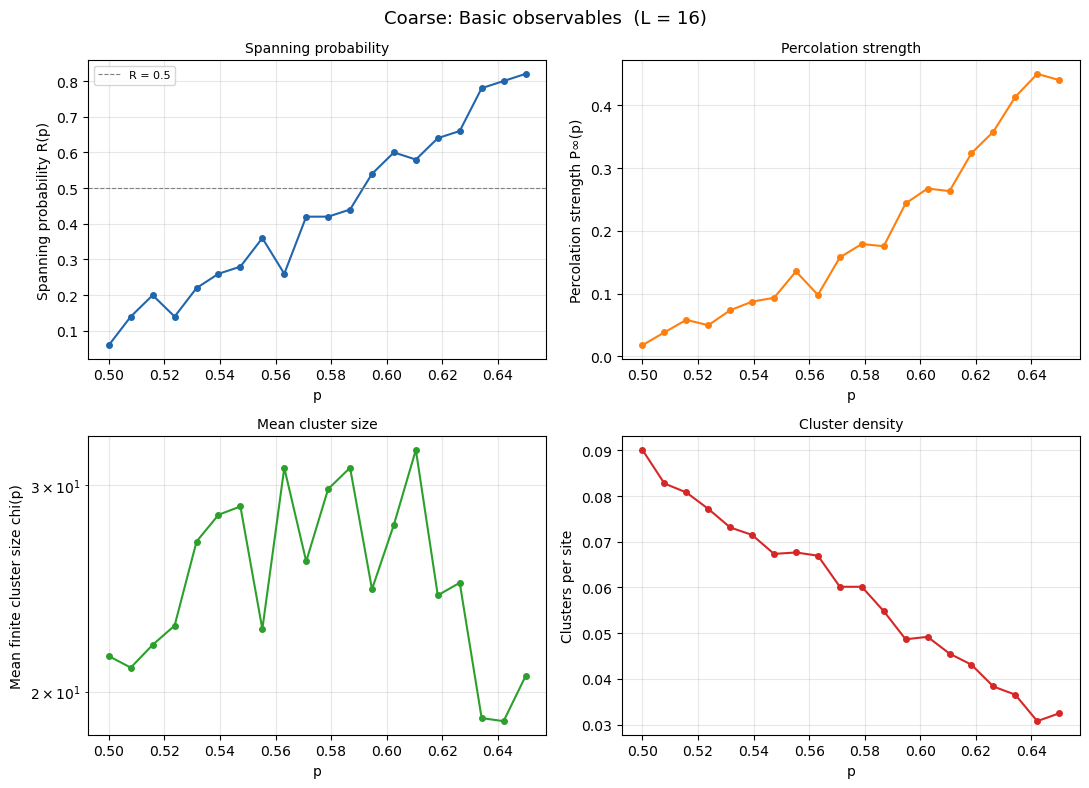

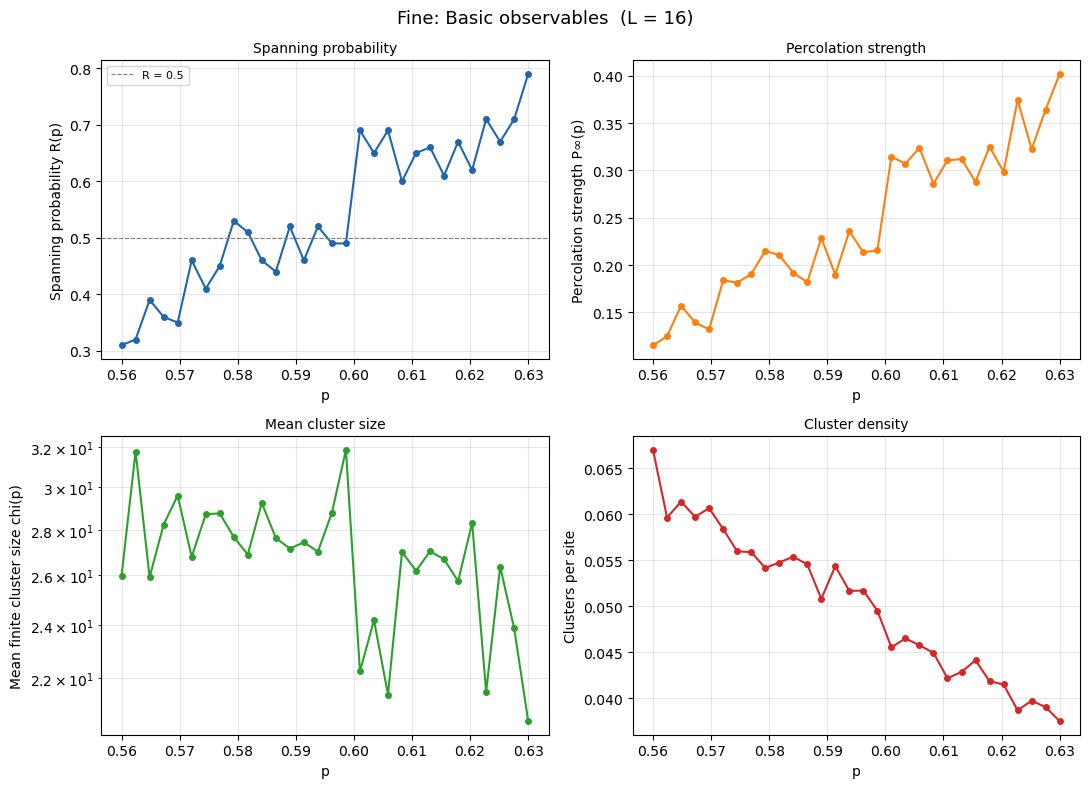

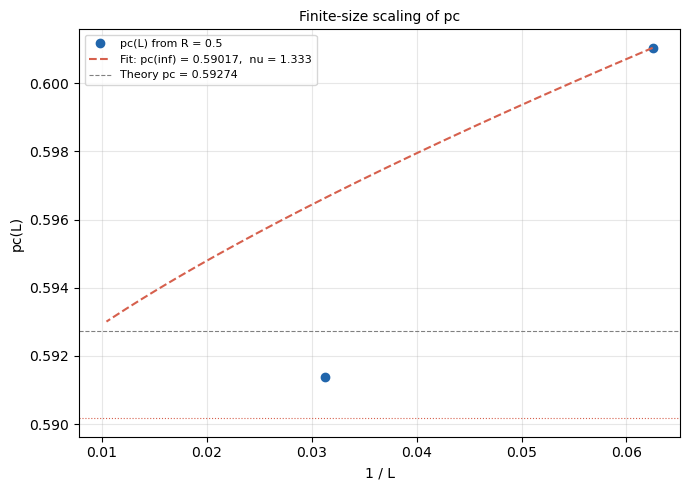

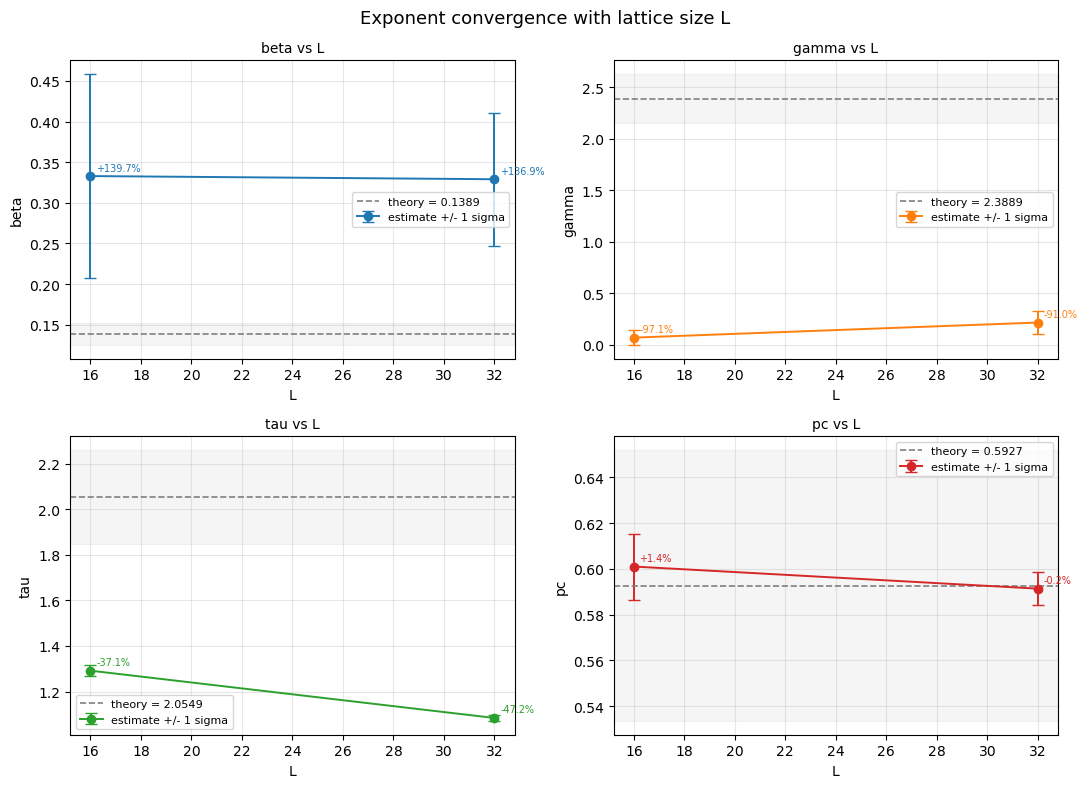

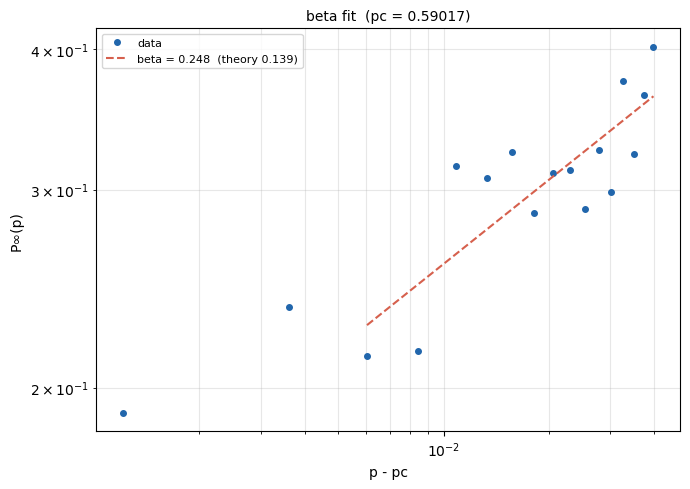

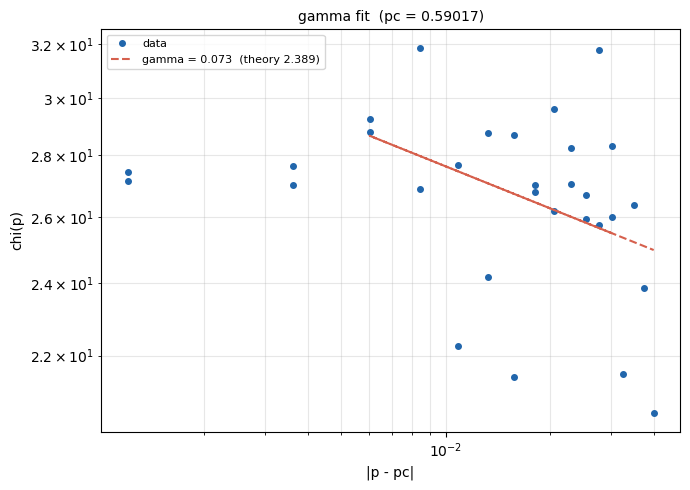

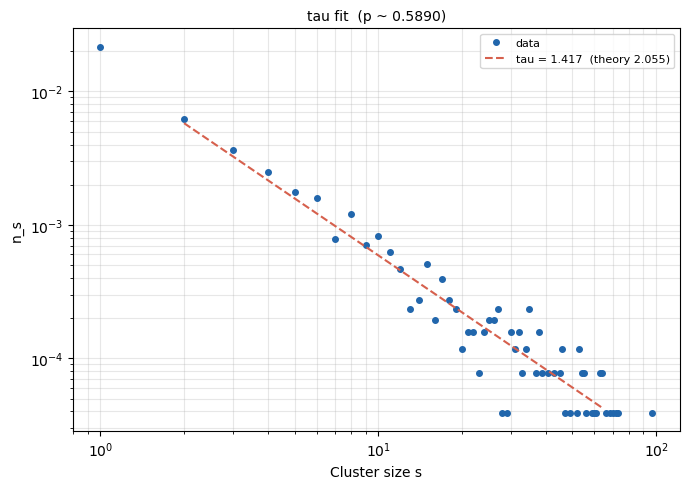

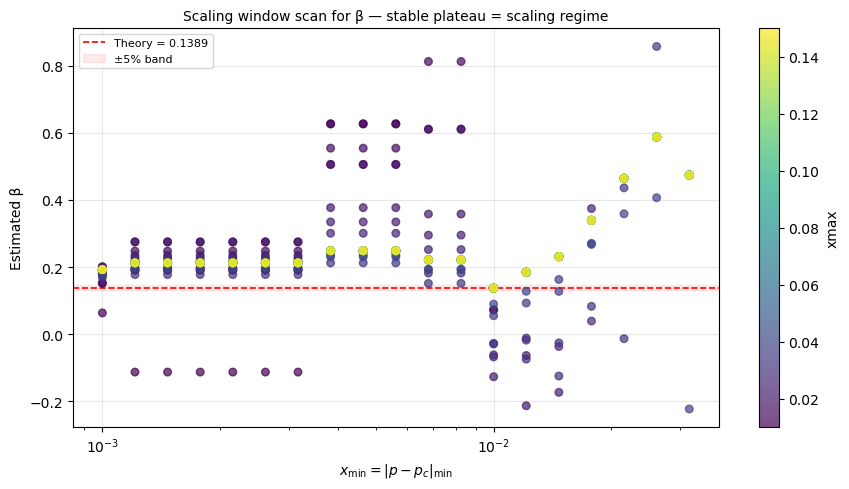

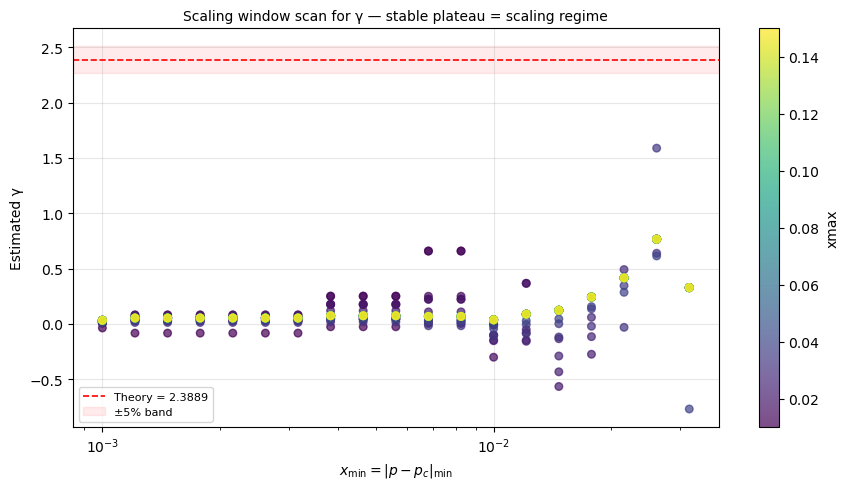

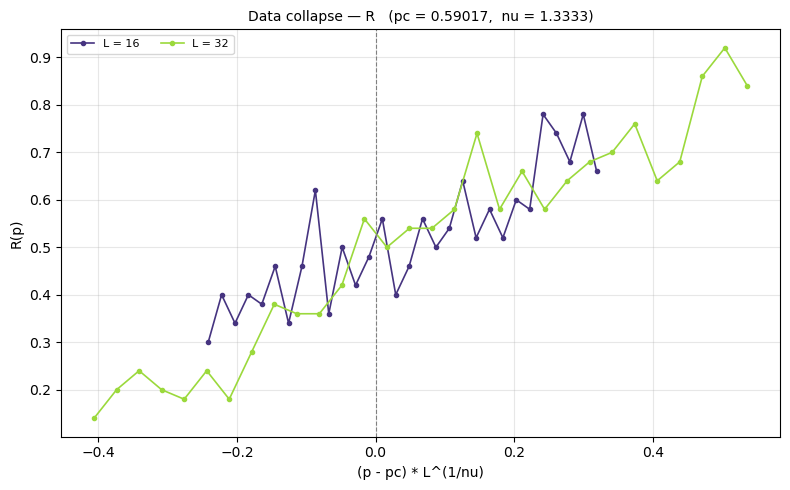

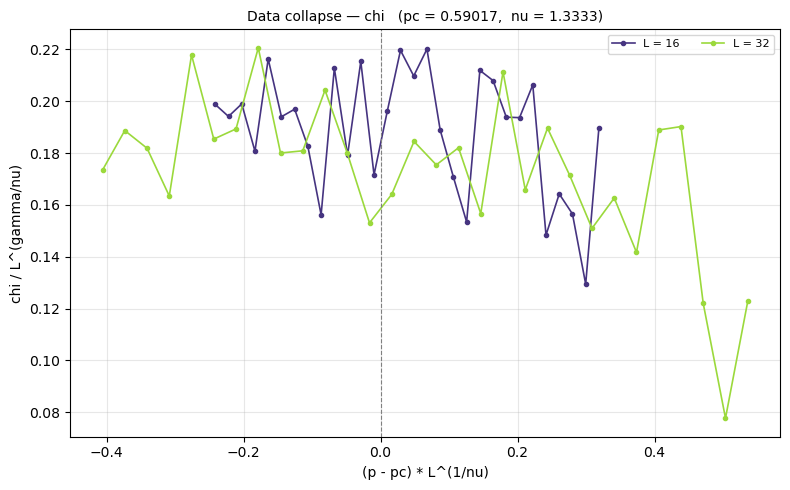

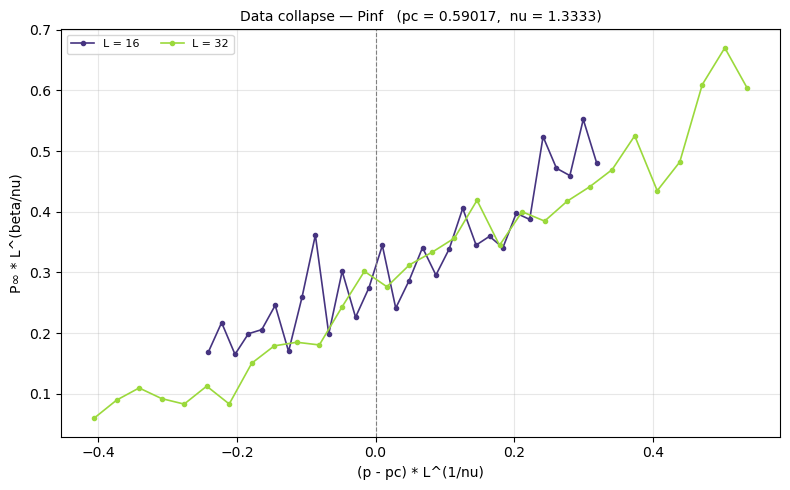

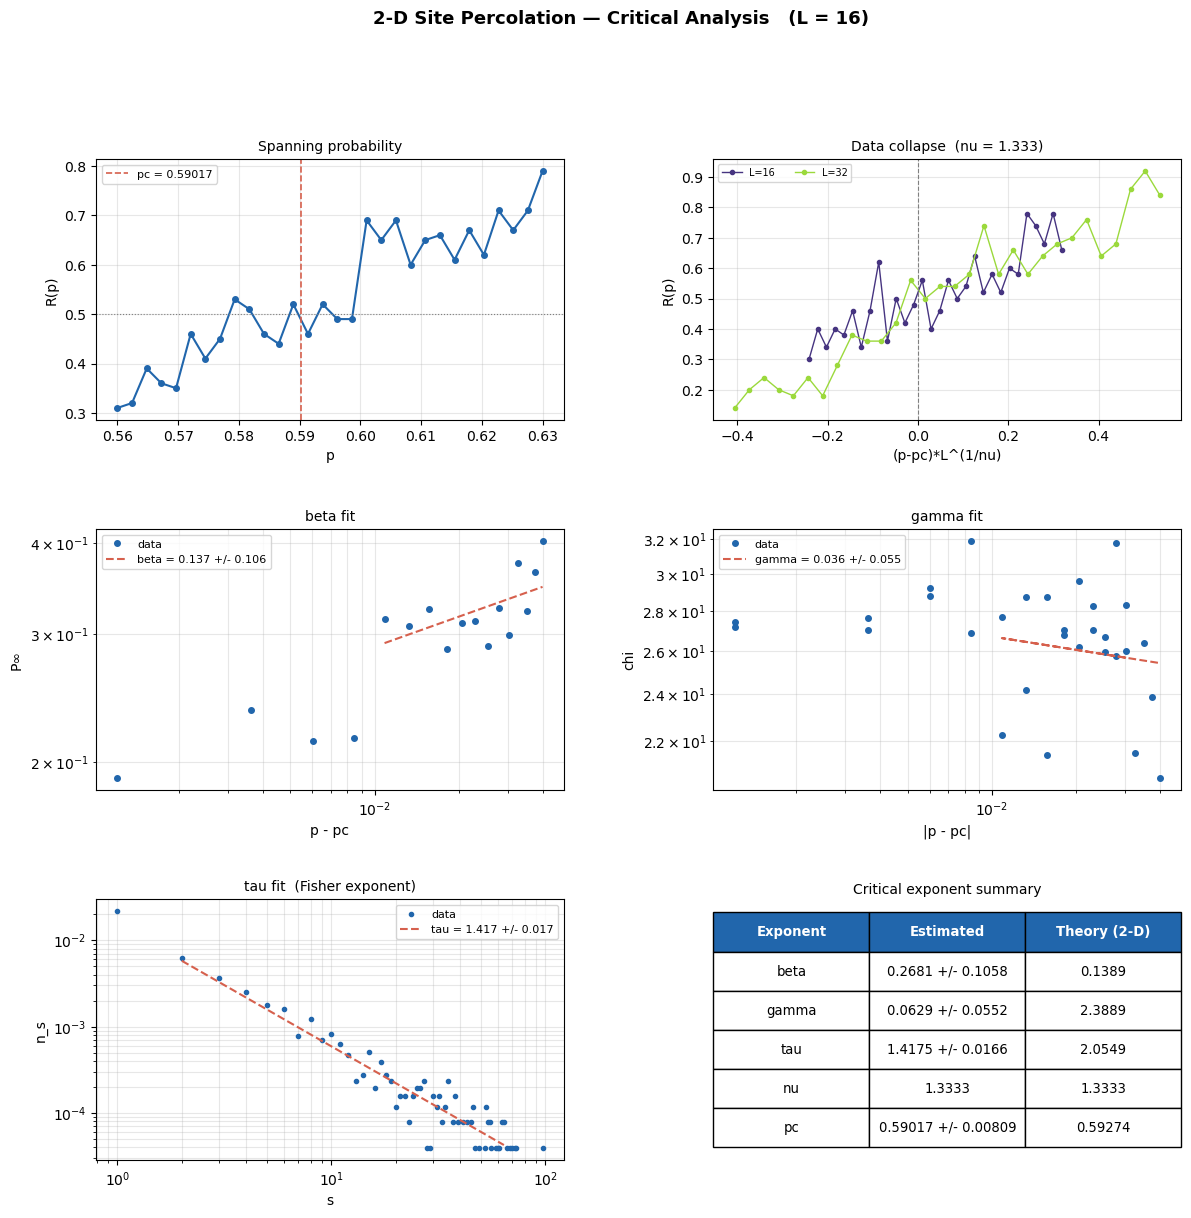

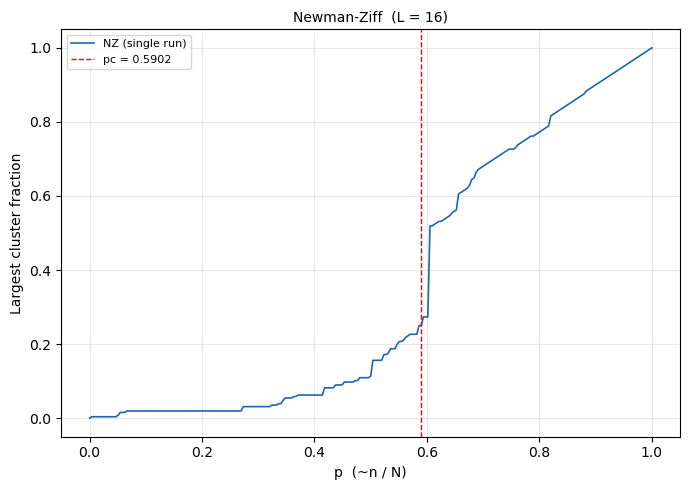

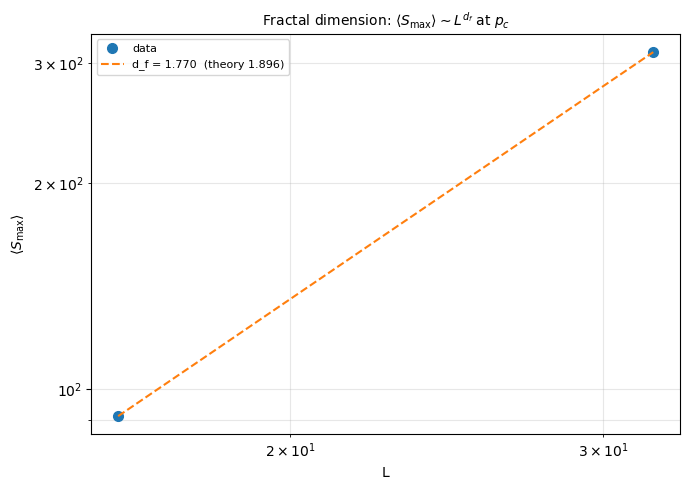

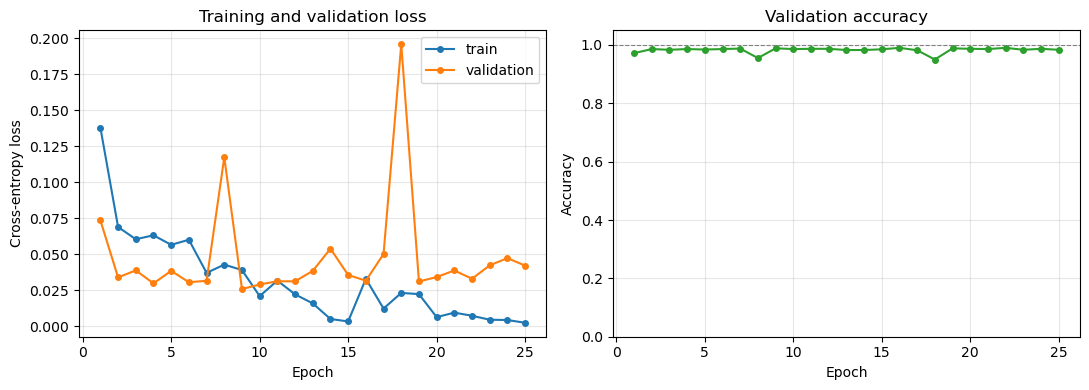

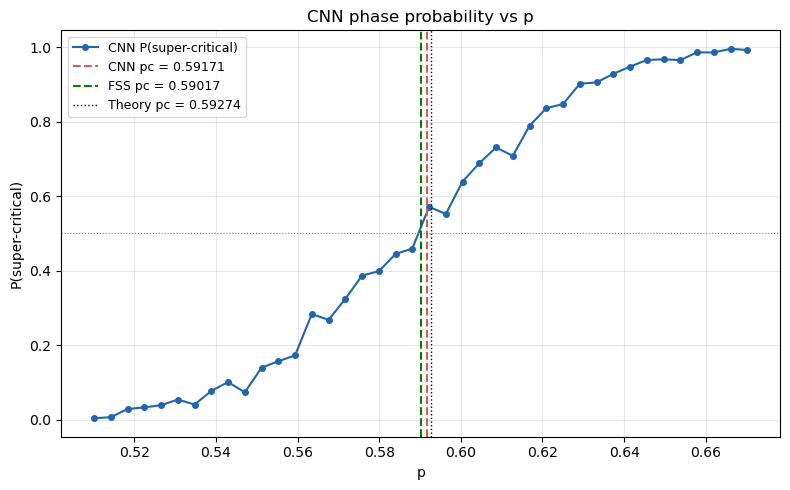

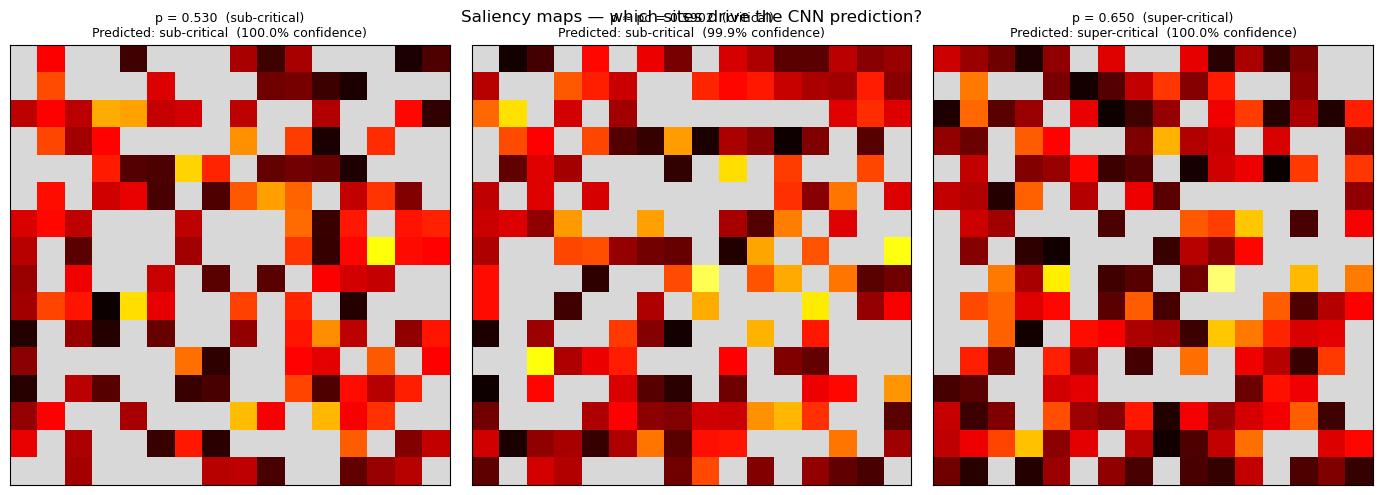

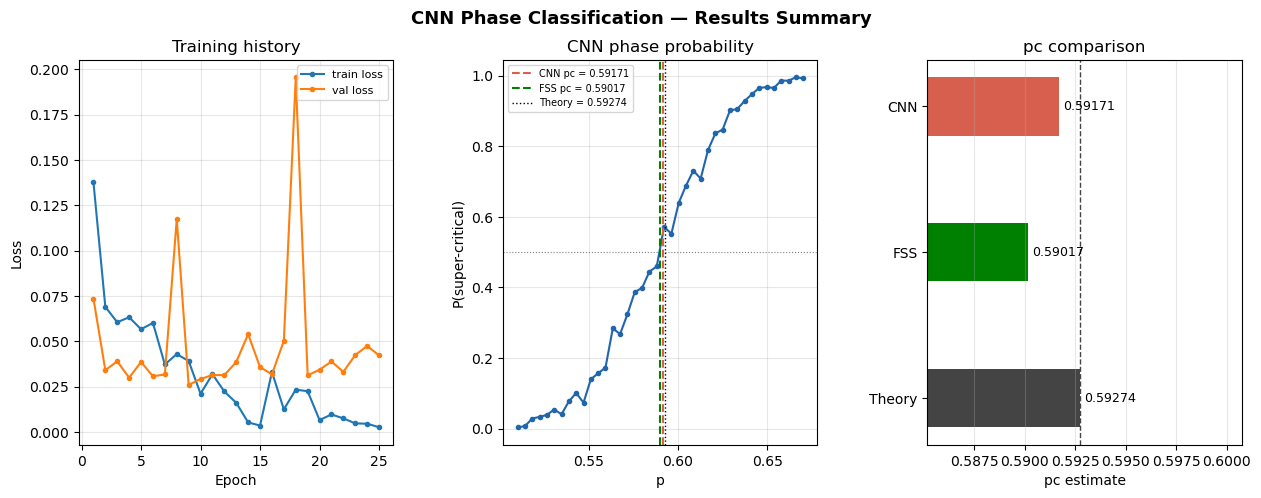

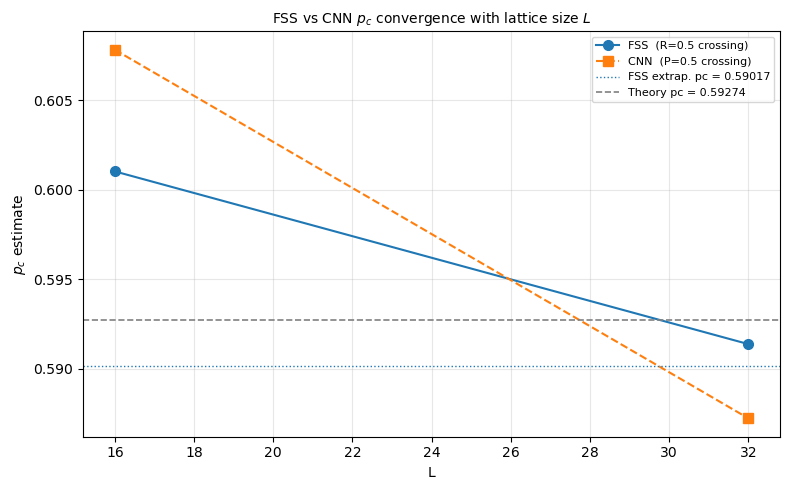

In [ ]:
"""
main.py
-------
Main entry point for the 2-D site-percolation study.

Workflow (9 steps)
------------------
1. Coarse sweep over p at L_MAIN to locate pc roughly.
2. Fine sweep near pc with more runs (stores per-run data for bootstrap).
3. FSS loop: pc(L), exponents, fractal dimension, uncertainties at each L.
4. Bootstrap uncertainties on the fine-sweep data.
5. Extract and print exponents with error bars.
5b. Scaling correction window scans for beta and gamma.
6. Data collapse using the FSS results.
7. Summary figure and Newman-Ziff cross-check.
8. Fractal dimension plot from FSS data.
9. CNN phase classifier: train at each L, compare pc convergence to FSS.

Edit the configuration block below to trade speed for accuracy.
Set RUN_ML = False to skip the ML step entirely.
"""

import os
import numpy as np
import matplotlib

from algorithms import hoshen_kopelman, newman_ziff
from simulation import estimate_observables_over_p
from analysis   import (
    estimate_pc_single_L, estimate_pc_fss,
    estimate_beta, estimate_gamma, estimate_tau,
    bootstrap_uncertainties, full_exponent_report,
    scaling_window_scan, optimal_window, THEORY,
)
from plotting import (
    plot_basic_observables, plot_beta_fit, plot_gamma_fit,
    plot_tau_fit, plot_nz_curve, plot_pc_fss,
    plot_data_collapse, plot_summary, plot_exponent_convergence,
    plot_df_fit, plot_scaling_window, plot_ml_convergence,
)

# =============================================================================
# Configuration — edit here
# =============================================================================

L_MAIN      = 16               # primary lattice size
L_FSS       = [16, 32]  # sizes for finite-size scaling

RUNS_COARSE = 50               # runs for broad sweep and FSS loop
RUNS_FINE   = 100               # runs for fine sweep (more = better exponents)

P_COARSE    = np.linspace(0.50, 0.65, 20)   # broad grid to find pc
P_FINE      = np.linspace(0.56, 0.63, 30)   # narrow grid for fitting

SPAN_MODE   = "LR"              # spanning direction: "LR", "TB", or "ANY"

BETA_XMIN,  BETA_XMAX  = 0.005, 0.06   # fitting window for beta
GAMMA_XMIN, GAMMA_XMAX = 0.005, 0.06   # fitting window for gamma

# Scaling correction window scan — range of xmin/xmax values to probe
SCAN_XMINS = np.logspace(-3, -1, 25)
SCAN_XMAXS = np.logspace(-2, np.log10(0.15), 25)

N_BOOT      = 500               # bootstrap resamples (reduce for speed)
BASE_SEED   = 42                # set None for non-reproducible runs
FIG_DIR     = "figures"         # folder for saved figures ("" to skip)

# ML configuration
RUN_ML          = True          # set False to skip the ML step entirely
ML_EPOCHS       = 25            # training epochs (20-30 is usually enough)
ML_SAMPLES_PER_P= 300           # lattices per p value for training
ML_P_GAP        = 0.04          # half-width of gap around pc in training data
ML_EVAL_SAMPLES = 300           # lattices per p for the pc curve

# =============================================================================
# Helpers
# =============================================================================

def _save(fig, name):
    if FIG_DIR:
        os.makedirs(FIG_DIR, exist_ok=True)
        path = os.path.join(FIG_DIR, f"{name}.png")
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {path}")


def _run(L, p_values, runs, seed_offset=0, return_runs=False, desc=None):
    """Convenience wrapper around estimate_observables_over_p."""
    return estimate_observables_over_p(
        L=L, p_values=p_values, runs=runs,
        span_mode=SPAN_MODE, n_jobs=-1,
        base_seed=BASE_SEED + seed_offset,
        return_runs=return_runs,
        desc=desc,
    )


def _collect_estimates(res, pc_L, L_val):
    """Extract point estimates from a single-L results dict."""
    est = {"pc": pc_L}
    k   = int(np.argmin(np.abs(res["p"] - pc_L)))
    for key, fn, obs in [("beta",  estimate_beta,  res["Pinf"]),
                          ("gamma", estimate_gamma, res["chi"])]:
        try:
            est[key], _, _ = fn(res["p"], obs, pc_L,
                                xmin=BETA_XMIN if key=="beta" else GAMMA_XMIN,
                                xmax=BETA_XMAX if key=="beta" else GAMMA_XMAX)
        except Exception:
            est[key] = None
    try:
        est["tau"], _, _, _ = estimate_tau(res["ns_density"][k],
                                           smin=2, smax=L_val*L_val//4)
    except Exception:
        est["tau"] = None
    return est

# =============================================================================
# Main
# =============================================================================

def main():
    print("=" * 60)
    print("  2-D Site Percolation  —  critical exponent analysis")
    print("=" * 60)

    # ------------------------------------------------------------------
    # Step 1: Coarse sweep
    # ------------------------------------------------------------------
    print(f"\n[1/7] Coarse sweep  L={L_MAIN}, runs={RUNS_COARSE} ...")
    coarse   = _run(L_MAIN, P_COARSE, RUNS_COARSE,
                    desc=f"[1/7] Coarse sweep  L={L_MAIN}")
    pc_coarse = estimate_pc_single_L(coarse["p"], coarse["R"])
    print(f"    pc (coarse) ≈ {pc_coarse:.5f}  [theory: {THEORY['pc']:.5f}]")
    _save(plot_basic_observables(coarse, L_MAIN, "Coarse: "), "coarse_observables")

    # ------------------------------------------------------------------
    # Step 2: Fine sweep  (stores per-run arrays for bootstrap)
    # ------------------------------------------------------------------
    print(f"\n[2/7] Fine sweep  L={L_MAIN}, runs={RUNS_FINE} ...")
    fine    = _run(L_MAIN, P_FINE, RUNS_FINE, seed_offset=10000,
                   return_runs=True,
                   desc=f"[2/7] Fine sweep    L={L_MAIN}")
    pc_fine = estimate_pc_single_L(fine["p"], fine["R"])
    print(f"    pc (fine)   ≈ {pc_fine:.5f}  [theory: {THEORY['pc']:.5f}]")
    _save(plot_basic_observables(fine, L_MAIN, "Fine: "), "fine_observables")

    # ------------------------------------------------------------------
    # Step 3: FSS loop — pc(L), exponents, uncertainties at each L
    # ------------------------------------------------------------------
    print(f"\n[3/7] Finite-size scaling  L = {L_FSS} ...")
    pc_of_L, results_by_L, estimates_by_L, uncertainties_by_L = [], {}, {}, {}
    Smax_at_pc = {}   # {L_val: mean largest cluster size at pc} for d_f fit

    for L_val in L_FSS:
        res = _run(L_val, P_FINE, RUNS_COARSE,
                   seed_offset=20000 + L_val, return_runs=True,
                   desc=f"[3/7] FSS  L={L_val:4d}")
        results_by_L[L_val] = res

        try:    pc_L = estimate_pc_single_L(res["p"], res["R"])
        except: pc_L = np.nan; print(f"    Warning: R(p) misses 0.5 for L={L_val}")
        pc_of_L.append(pc_L)
        print(f"    L = {L_val:4d}  →  pc(L) = {pc_L:.5f}")

        # Largest cluster at the p closest to pc — used for fractal dimension
        k_pc = int(np.argmin(np.abs(res["p"] - pc_L)))
        Smax_at_pc[L_val] = float(res["Smax"][k_pc])

        estimates_by_L[L_val] = _collect_estimates(res, pc_L, L_val)

        try:
            uncertainties_by_L[L_val] = bootstrap_uncertainties(
                res, pc_L, n_boot=min(N_BOOT, 200),
                beta_xmin=BETA_XMIN, beta_xmax=BETA_XMAX,
                gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
                L=L_val,
                rng=np.random.default_rng(BASE_SEED + 30000 + L_val),
            )
        except Exception as e:
            print(f"    Bootstrap for L={L_val} failed: {e}")

    L_arr    = np.array(L_FSS,   dtype=float)
    pc_L_arr = np.array(pc_of_L, dtype=float)
    valid    = np.isfinite(pc_L_arr)

    pc_best, nu_fit = pc_fine, THEORY["nu"]
    if valid.sum() >= 3:
        try:
            pc_best, nu_fit, _ = estimate_pc_fss(L_arr[valid], pc_L_arr[valid])
            print(f"\n    FSS: pc(∞) = {pc_best:.5f},  nu = {nu_fit:.4f}"
                  f"  [theory nu = {THEORY['nu']:.4f}]")
        except Exception as e:
            print(f"    FSS fit failed: {e}; using single-L pc.")
    else:
        print("    Not enough valid points for FSS; using single-L pc.")

    print(f"\n  *** Best pc: {pc_best:.5f}  (theory: {THEORY['pc']:.5f}) ***")

    _save(plot_pc_fss(L_arr[valid], pc_L_arr[valid],
                      pc_inf=pc_best, nu=nu_fit), "pc_fss")
    _save(plot_exponent_convergence(L_arr[valid], estimates_by_L,
                                    uncertainties_by_L), "exponent_convergence")

    # ------------------------------------------------------------------
    # Step 4: Bootstrap on fine sweep
    # ------------------------------------------------------------------
    print(f"\n[4/7] Bootstrap uncertainties  (n_boot={N_BOOT}) ...")
    unc = bootstrap_uncertainties(
        fine, pc_best, n_boot=N_BOOT,
        beta_xmin=BETA_XMIN, beta_xmax=BETA_XMAX,
        gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
        L=L_MAIN, rng=np.random.default_rng(BASE_SEED + 50000),
    )

    # ------------------------------------------------------------------
    # Step 5: Exponent report
    # ------------------------------------------------------------------
    print(f"\n[5/7] Extracting critical exponents ...")
    full_exponent_report(fine, pc=pc_best, L=L_MAIN,
                         beta_xmin=BETA_XMIN,  beta_xmax=BETA_XMAX,
                         gamma_xmin=GAMMA_XMIN, gamma_xmax=GAMMA_XMAX,
                         uncertainties=unc)

    for name, fn, kw in [("beta_fit",  plot_beta_fit,
                           dict(xmin=BETA_XMIN,  xmax=BETA_XMAX)),
                          ("gamma_fit", plot_gamma_fit,
                           dict(xmin=GAMMA_XMIN, xmax=GAMMA_XMAX)),
                          ("tau_fit",   plot_tau_fit,   dict(L=L_MAIN))]:
        print(f"  Plotting {name} ...")
        fig, _ = fn(fine, pc_best, **kw)
        _save(fig, name)

    # ------------------------------------------------------------------
    # Step 5b: Scaling correction window scans
    # ------------------------------------------------------------------
    print(f"\n[5b] Scaling correction window scan ...")
    for obs_type, obs_arr, sym, tv in [
        ("beta",  fine["Pinf"], "beta",  THEORY["beta"]),
        ("gamma", fine["chi"],  "gamma", THEORY["gamma"]),
    ]:
        scan = scaling_window_scan(
            fine["p"], obs_arr, pc_best,
            obs_type=obs_type,
            xmins=SCAN_XMINS, xmaxs=SCAN_XMAXS,
        )
        best = optimal_window(scan, tv)
        if best:
            print(f"    Best {sym} window: xmin={best['xmin']:.4f}, "
                  f"xmax={best['xmax']:.4f}  →  {sym}={best['exponent']:.4f}"
                  f"  (theory {tv:.4f})")
        _save(plot_scaling_window(scan, obs_type=obs_type, theory_val=tv),
              f"scaling_window_{obs_type}")

    # ------------------------------------------------------------------
    # Step 6: Data collapse (reuses results_by_L — no extra simulation)
    # ------------------------------------------------------------------
    print(f"\n[6/9] Data collapse  (L = {L_FSS}) ...")
    for obs in ("R", "chi", "Pinf"):
        print(f"  Plotting collapse ({obs}) ...")
        try:
            _save(plot_data_collapse(results_by_L, pc=pc_best,
                                     nu=nu_fit, observable=obs),
                  f"collapse_{obs}")
        except Exception as e:
            print(f"  Collapse ({obs}) failed: {e}")

    # ------------------------------------------------------------------
    # Step 7: Summary figure + Newman-Ziff
    # ------------------------------------------------------------------
    print(f"\n[7/9] Summary figure and Newman-Ziff ...")
    print(f"  Plotting summary figure ...")
    _save(plot_summary(fine, pc=pc_best, L=L_MAIN, nu=nu_fit,
                       uncertainties=unc, results_by_L=results_by_L),
          "summary")
    print(f"  Running Newman-Ziff ...")
    largest = newman_ziff(L_MAIN, rng=np.random.default_rng(BASE_SEED + 99999))
    _save(plot_nz_curve(largest, L_MAIN, pc=pc_best), "newman_ziff")

    # ------------------------------------------------------------------
    # Step 8: Fractal dimension from FSS data
    # ------------------------------------------------------------------
    print(f"\n[8/9] Fractal dimension ...")
    L_df   = np.array([L for L in L_FSS if L in Smax_at_pc], dtype=float)
    S_df   = np.array([Smax_at_pc[int(L)] for L in L_df], dtype=float)
    try:
        print(f"  Fitting d_f from {len(L_df)} lattice sizes ...")
        fig, df_est = plot_df_fit(L_df, S_df)
        _save(fig, "fractal_dimension")
        print(f"    d_f = {df_est:.4f}  [theory: {THEORY['df']:.4f}]")
    except Exception as e:
        print(f"    Fractal dimension fit failed: {e}")

    print("\nDone. All figures saved to:", FIG_DIR or "(display only)")

    # ------------------------------------------------------------------
    # Step 9: CNN phase classifier + pc convergence vs L
    # ------------------------------------------------------------------
    if not RUN_ML:
        print("\n[ML step skipped — set RUN_ML=True to enable]")
        return

    print(f"\n[9/9] CNN phase classifier ...")
    try:
        from ml_analysis import (
            run_ml_pipeline, plot_training_history,
            plot_cnn_pc_curve, plot_saliency, plot_ml_summary,
        )
    except ImportError:
        print("  PyTorch not found — install with: pip install torch")
        print("  Skipping ML step.")
        return

    # Train at L_MAIN for the main pc estimate and figures
    print(f"\n  [9a] Training CNN at L={L_MAIN} ({ML_EPOCHS} epochs) ...")
    ml = run_ml_pipeline(
        L            = L_MAIN,
        pc_fss       = pc_best,
        samples_per_p= ML_SAMPLES_PER_P,
        p_gap        = ML_P_GAP,
        n_epochs     = ML_EPOCHS,
        eval_samples = ML_EVAL_SAMPLES,
        seed         = BASE_SEED + 77777,
        save_path    = os.path.join(FIG_DIR, "percolation_cnn.pt"),
    )

    print(f"  [9a] Plotting ML figures ...")
    _save(plot_training_history(ml["history"]),           "ml_training")
    print(f"    ml_training saved")
    _save(plot_cnn_pc_curve(ml["p_eval"], ml["prob_super"],
                             ml["pc_cnn"], pc_fss=pc_best), "ml_pc_curve")
    print(f"    ml_pc_curve saved")
    _save(plot_saliency(ml["model"], L_MAIN, pc_best,
                        device=ml["device"]),              "ml_saliency")
    print(f"    ml_saliency saved")
    _save(plot_ml_summary(ml["history"], ml["p_eval"],
                           ml["prob_super"], ml["pc_cnn"],
                           pc_fss=pc_best),                "ml_summary")
    print(f"    ml_summary saved")

    # Train at each FSS L to build the convergence comparison
    print(f"\n  [9b] CNN pc convergence — training at each L in {L_FSS} ...")
    pc_cnn_by_L = {}
    pc_fss_by_L = {int(L): estimates_by_L[int(L)]["pc"] for L in L_FSS
                   if int(L) in estimates_by_L}

    for i, L_val in enumerate(L_FSS, 1):
        print(f"  [{i}/{len(L_FSS)}] Training CNN at L={L_val} "
              f"({ML_EPOCHS} epochs) ...")
        pc_fss_L = pc_fss_by_L.get(L_val, pc_best)
        try:
            ml_L = run_ml_pipeline(
                L            = L_val,
                pc_fss       = pc_fss_L,
                samples_per_p= max(ML_SAMPLES_PER_P // 2, 100),
                p_gap        = ML_P_GAP,
                n_epochs     = ML_EPOCHS,
                eval_samples = max(ML_EVAL_SAMPLES // 2, 100),
                seed         = BASE_SEED + 77777 + L_val,
                save_path    = None,
            )
            pc_cnn_by_L[L_val] = ml_L["pc_cnn"]
            print(f"    Done — CNN pc = {ml_L['pc_cnn']:.5f}  "
                  f"FSS pc = {pc_fss_L:.5f}")
        except Exception as e:
            print(f"    L={L_val} CNN failed: {e}")

    if pc_cnn_by_L:
        print(f"  Plotting ML convergence figure ...")
        _save(plot_ml_convergence(
            L_arr      = L_FSS,
            pc_fss_by_L= pc_fss_by_L,
            pc_cnn_by_L= pc_cnn_by_L,
            pc_inf_fss = pc_best,
        ), "ml_convergence")

    print(f"\n  pc comparison (L={L_MAIN}):")
    print(f"    Theory : {THEORY['pc']:.5f}")
    print(f"    FSS    : {pc_best:.5f}")
    print(f"    CNN    : {ml['pc_cnn']:.5f}")


if __name__ == "__main__":
    main()